# Pré-aula — Execute uma vez antes de apresentar

Este bloco prepara ambiente e dados para a aula.

- **Pré-requisitos:** Python 3, `pandas` e `matplotlib`.
- **Saída esperada:** `ratings.csv` e `movies.csv` em `data/movielens/`.
- **Fallback:** sem internet, use arquivos locais na pasta `data/movielens/`.

Execute as próximas células antes de iniciar a apresentação.

## Instrução rápida de pré-aula
1. Execute os imports e o setup de dados.
2. Confirme que os arquivos foram carregados sem erro.
3. Inicie a apresentação a partir da seção **Início da aula**.

In [1]:
from pathlib import Path
import zipfile
import urllib.error
import urllib.request

import matplotlib.pyplot as plt
import pandas as pd

SEED = 42
DATA_DIR = Path('data/movielens')
ZIP_PATH = DATA_DIR / 'ml-latest-small.zip'
EXTRACT_DIR = DATA_DIR / 'ml-latest-small'
RATINGS_PATH = DATA_DIR / 'ratings.csv'
MOVIES_PATH = DATA_DIR / 'movies.csv'
MOVIELENS_URL = 'https://files.grouplens.org/datasets/movielens/ml-latest-small.zip'

DATA_DIR.mkdir(parents=True, exist_ok=True)
print('Diretório de dados:', DATA_DIR.resolve())

Diretório de dados: /home/drl/fiap/rl-ai-scientist/notebooks/aula01/data/movielens


In [2]:
def _validar_arquivo(path: Path, colunas_obrigatorias: set[str] | None = None) -> tuple[bool, str]:
    if not path.exists():
        return False, f'Arquivo ausente: {path}'
    if path.stat().st_size == 0:
        return False, f'Arquivo vazio: {path}'
    if colunas_obrigatorias:
        try:
            df = pd.read_csv(path, nrows=5)
        except Exception as exc:
            return False, f'Falha ao ler CSV {path}: {exc}'
        faltantes = sorted(colunas_obrigatorias.difference(df.columns))
        if faltantes:
            return False, f'Colunas obrigatorias ausentes em {path.name}: {faltantes}'
    return True, 'OK'


def setup_movielens() -> tuple[Path, Path]:
    """Prepara ratings.csv e movies.csv em data/movielens/."""
    src_ratings = EXTRACT_DIR / 'ratings.csv'
    src_movies = EXTRACT_DIR / 'movies.csv'

    if RATINGS_PATH.exists() and MOVIES_PATH.exists():
        print('Dados locais encontrados. Setup concluido sem download.')
        return RATINGS_PATH, MOVIES_PATH

    try:
        if not ZIP_PATH.exists():
            print('Baixando MovieLens Small...')
            urllib.request.urlretrieve(MOVIELENS_URL, ZIP_PATH)
        if not EXTRACT_DIR.exists():
            with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
                zf.extractall(DATA_DIR)
        if src_ratings.exists() and not RATINGS_PATH.exists():
            RATINGS_PATH.write_bytes(src_ratings.read_bytes())
        if src_movies.exists() and not MOVIES_PATH.exists():
            MOVIES_PATH.write_bytes(src_movies.read_bytes())
    except (urllib.error.URLError, zipfile.BadZipFile) as exc:
        print('Falha ao preparar dataset automaticamente:', exc)
        print('Use arquivos locais em data/movielens/ para continuar.')

    ok_ratings, msg_ratings = _validar_arquivo(RATINGS_PATH, {'userId', 'movieId', 'rating'})
    ok_movies, msg_movies = _validar_arquivo(MOVIES_PATH, {'movieId', 'title'})

    print('ratings.csv:', msg_ratings)
    print('movies.csv:', msg_movies)
    return RATINGS_PATH, MOVIES_PATH

In [3]:
ratings_path, movies_path = setup_movielens()
ratings = pd.read_csv(ratings_path) if ratings_path.exists() else pd.DataFrame()
movies = pd.read_csv(movies_path) if movies_path.exists() else pd.DataFrame()

if ratings.empty or not {'userId', 'movieId', 'rating'}.issubset(ratings.columns):
    raise RuntimeError(
        'Dados de ratings invalidos para a aula. Verifique download/arquivos em data/movielens/ e rode novamente.'
    )

if movies.empty or not {'movieId', 'title'}.issubset(movies.columns):
    raise RuntimeError(
        'Dados de movies invalidos para a aula. Verifique download/arquivos em data/movielens/ e rode novamente.'
    )

print('Pre-aula concluida. Inicie a apresentacao na secao: Inicio da aula.')

Dados locais encontrados. Setup concluido sem download.
Pre-aula concluida. Inicie a apresentacao na secao: Inicio da aula.


---
## Início da aula

# 01 — Contexto MovieLens

## Bloco 1 — Contexto e pergunta

Uma plataforma de streaming quer melhorar a experiência dos usuários por meio de recomendações mais relevantes. O problema de negócio pode ser resumido em uma pergunta direta:

**Como recomendar melhores filmes?**

Essa pergunta não corresponde a uma única tarefa técnica. Dependendo do que a plataforma quer saber, ela se desdobra em três formulações distintas:

| Formulação | Paradigma de ML |
|---|---|
| O usuário vai gostar de um filme específico? | Supervisionado |
| Que tipos de usuários ou filmes existem? | Não supervisionado |
| Qual filme recomendar agora para maximizar engajamento futuro? | Aprendizado por Reforço |

O **MovieLens** será o dataset utilizado nas três formulações ao longo desta aula. O mesmo conjunto de dados — usuários, filmes, notas — responde a perguntas diferentes conforme a formulação escolhida.

## Informações do notebook

| Item | Detalhe |
|---|---|
| **Aula** | Aula 01 — Paradigmas de ML com MovieLens |
| **Notebook** | 01 — Contexto MovieLens |
| **Seções** | 1.1 — Exploração do dataset |
| **Tempo de leitura** | 10 min |
| **Tempo de execução (padrão)** | 3–5 min |
| **Exercícios** | 5 questões de autoavaliação |

### Pré-requisitos

- **Conceitos:** nenhum — este é o notebook introdutório da aula.

### Competências para o Desafio Final

- Carregar e explorar o dataset MovieLens, identificando as tabelas e colunas relevantes.
- Derivar a variável de recompensa (`recompensa = nota ≥ 4`) a partir das avaliações brutas.
- Descrever por que o mesmo dataset suporta três formulações de ML distintas.

In [4]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))

import rl_utils
rl_utils.info_versoes()
rl_utils.configurar_matplotlib()
rl_utils.definir_seeds(42)

Biblioteca           Versão
--------------------------------
gymnasium            1.0.0


torch                2.11.0+cpu
numpy                2.4.2
matplotlib           3.10.8
pandas               3.0.1


scikit-learn         1.8.0


## Bloco 2 — Mini teoria

### O que é o MovieLens

O MovieLens é um dataset público de avaliações de filmes mantido pelo grupo GroupLens da Universidade de Minnesota. A versão utilizada nesta aula (*ml-latest-small*) contém aproximadamente 100 mil avaliações, cobrindo cerca de 600 usuários e 9 mil filmes.

### Estrutura das tabelas

O dataset é composto por duas tabelas principais, unidas pela chave `movieId`.

**`ratings.csv`** — interações usuário-filme:

| Coluna | Tipo | Significado |
|---|---|---|
| `userId` | inteiro | Identificador único do usuário |
| `movieId` | inteiro | Identificador único do filme |
| `rating` | decimal | Nota atribuída (0,5 a 5,0 em incrementos de 0,5) |
| `timestamp` | inteiro | Momento da avaliação (Unix epoch) |

**`movies.csv`** — metadados dos filmes:

| Coluna | Tipo | Significado |
|---|---|---|
| `movieId` | inteiro | Chave de junção com `ratings` |
| `title` | texto | Título do filme com ano de lançamento |
| `genres` | texto | Gêneros separados por `\|` (ex.: `Action\|Comedy`) |

### O mesmo dataset, três sinais distintos

Os paradigmas de ML não diferem apenas no algoritmo — diferem no **tipo de pergunta** e no **sinal disponível para aprendizado**:

- No **supervisionado**, `rating` fornece o rótulo: o par (`userId`, `movieId`) com a nota é o dado de treino. O modelo aprende a prever preferência.
- No **não supervisionado**, não há alvo explícito: o algoritmo descobre estrutura nos padrões de consumo, sem resposta correta definida.
- No **Aprendizado por Reforço**, `rating` vira `recompensa`: o sistema age, observa o feedback e ajusta a estratégia ao longo do tempo.

## Bloco 3 — Código didático mínimo

In [5]:
print('Avaliações (ratings) — primeiras linhas:')
display(ratings.head())

print('\nFilmes (movies) — primeiras linhas:')
display(movies.head())

Avaliações (ratings) — primeiras linhas:


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931



Filmes (movies) — primeiras linhas:


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [6]:
generos_unicos = (
    movies['genres'].str.split('|').explode()
    .replace('(no genres listed)', pd.NA)
    .dropna()
    .nunique()
) if not movies.empty else 0

panorama = pd.DataFrame([{
    'usuarios_unicos': int(ratings['userId'].nunique()),
    'filmes_unicos':   int(ratings['movieId'].nunique()),
    'generos_unicos':  int(generos_unicos),
    'avaliacoes':      int(len(ratings)),
    'nota_media':      round(float(ratings['rating'].mean()), 2),
}])

print('Panorama quantitativo:')
display(panorama)

Panorama quantitativo:


,usuarios_unicos,filmes_unicos,generos_unicos,avaliacoes,nota_media
0,610,9724,19,100836,3.5


Distribuição de notas:


,nota,quantidade
0,0.5,1370
1,1.0,2811
2,1.5,1791
3,2.0,7551
4,2.5,5550
5,3.0,20047
6,3.5,13136
7,4.0,26818
8,4.5,8551
9,5.0,13211


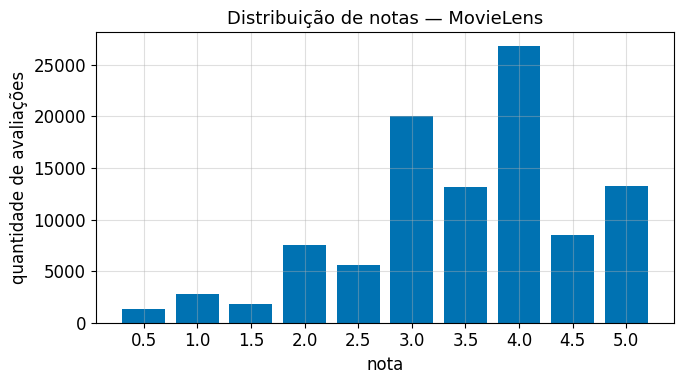

In [7]:
dist_notas = ratings['rating'].value_counts().sort_index()

print('Distribuição de notas:')
display(dist_notas.rename_axis('nota').reset_index(name='quantidade'))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(dist_notas.index, dist_notas.values, width=0.4)
ax.set_title('Distribuição de notas — MovieLens')
ax.set_xlabel('nota')
ax.set_ylabel('quantidade de avaliações')
ax.set_xticks(dist_notas.index)
plt.tight_layout()
plt.show()

## Bloco 4 — Interpretação pedagógica

### O que os dados revelam

**Distribuição de notas e desbalanceamento de classes**
A distribuição não é uniforme: notas inteiras predominam sobre meias notas, e a faixa 3,0–4,0 concentra a maioria das avaliações. Notas abaixo de 2,0 são raras. No supervisionado, isso significa que o alvo binário `gostou` (nota ≥ 4) terá classes desbalanceadas — um detalhe que afeta a escolha de métricas e o limiar de classificação.

**Volume de avaliações e esparsidade**
A base contém dezenas de milhares de avaliações, mas a relação entre avaliações observadas e combinações possíveis de (`userId`, `movieId`) é muito pequena. A maioria dos usuários avaliou uma fração mínima do catálogo disponível. Isso exige que qualquer abordagem generalize além dos pares observados — seja por predição supervisionada, seja por exploração no RL.

**Diversidade de gêneros e perfis de consumo**
Os filmes cobrem dezenas de gêneros distintos, e cada filme pode pertencer a múltiplos gêneros simultaneamente. Essa estrutura permite construir um vetor de preferência por gênero para cada usuário, que é a matéria-prima direta para o não supervisionado.

### Conexão com a pergunta de negócio

Cada característica observada se torna relevante em uma das três formulações:

| Observação | Implicação técnica |
|---|---|
| Notas concentradas em faixas altas | Desbalanceamento de classes no supervisionado |
| Maioria dos pares usuário-filme sem avaliação | Necessidade de generalização; justifica exploração no RL |
| Gêneros múltiplos por filme | Perfis de usuário interpretáveis para o não supervisionado |

## Bloco 5 — Limites e transição

### O que a exploração do dataset não resolve

Conhecer a estrutura do MovieLens não é suficiente para recomendar. A exploração mostra *o que existe* nos dados, mas não determina *como aprender* a partir deles. Para isso, é preciso formular uma pergunta precisa e identificar o tipo de sinal disponível.

Cada limitação identificada na exploração aponta para uma formulação específica:

- A ausência de avaliações para a maior parte dos pares usuário-filme não impede o supervisionado — o modelo aprende a generalizar a partir dos pares observados.
- Os padrões de consumo não têm rótulo explícito — o não supervisionado descobre estrutura sem alvo definido.
- O efeito cumulativo de uma sequência de recomendações não está codificado no dataset estático — o RL modela esse processo por interação.

### O que vem a seguir

O próximo notebook aborda a primeira formulação:

**Dado um usuário e um filme, o usuário vai gostar?**

Essa pergunta define o problema como supervisionado e introduz o conceito de rótulo explícito derivado da `rating`.

## O que você deve ser capaz de explicar ao final deste notebook

- [ ] Para que serve o MovieLens e o que cada tabela representa.
- [ ] O significado de `userId`, `movieId`, `rating` e `genres` e como as tabelas se relacionam via `movieId`.
- [ ] Por que o mesmo dataset gera três formulações distintas para supervisionado, não supervisionado e RL.
- [ ] O que a distribuição de notas revela e como isso afeta a formulação supervisionada.
- [ ] Por que explorar o dataset não é suficiente para resolver o problema de recomendação.

## Glossário — termos introduzidos neste notebook

| Termo (EN) | Tradução (PT) | Descrição |
|---|---|---|
| dataset | conjunto de dados | Coleção estruturada de observações usada para treinar e avaliar modelos. |
| sparsity | esparsidade | Proporção de pares (usuário, filme) sem avaliação registrada no dataset. |
| feature | feature / variável | Atributo de entrada usado pelo modelo para fazer previsões ou descobrir estrutura. |
| cold start | cold start | Dificuldade de recomendar para usuários ou itens sem histórico de avaliações. |
| rating | avaliação | Nota atribuída por um usuário a um filme; sinal central do MovieLens (0,5–5,0). |

> Glossário completo do curso: [docs/glossario.md](../../docs/glossario.md)

## Leituras e referencias
- MovieLens (GroupLens): https://grouplens.org/datasets/movielens/ (acesso em 2026-03-07)
- Harper, F. M.; Konstan, J. A. (2015). The MovieLens Datasets: History and Context.
- Roteiro da Aula 01: `roteiros/Aula 01 - Roteiro video aula.md`
- Mapa da Aula 01: `docs/aulas/aula01-mapa.md`
- Guia de navegacao da aula: `notebooks/aula01/00_guia_aula01.ipynb`